In [ ]:
# 1. Install & Initialize PyRosetta
!pip install -q pyrosetta-installer
import pyrosetta_installer
pyrosetta_installer.install_pyrosetta()

import pyrosetta
pyrosetta.init("-mute all")

Installing PyRosetta:
 os: ubuntu
 type: Release
 Rosetta C++ extras: 
 mirror: https://west.rosettacommons.org/pyrosetta/release/release
 extra packages: numpy

PyRosetta wheel url: https://:@west.rosettacommons.org/pyrosetta/release/release/PyRosetta4.Release.python313.ubuntu.wheel/pyrosetta-2026.39+release.49e05e797c-cp313-cp313-linux_x86_64.whl
┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────

In [ ]:
from pyrosetta import toolbox
from pyrosetta.rosetta.protocols.simple_moves import MutateResidue

# Download Ubiquitin (1UBQ)
wt_pose = toolbox.rcsb.pose_from_rcsb("1UBQ")

# Create Mutant (I36A)
mutant_pose = wt_pose.clone()
mut = MutateResidue(target=36, new_res="ALA")
mut.apply(mutant_pose)

print(f"Wild-Type residue 36: {wt_pose.residue(36).name3()}")
print(f"Mutant residue 36   : {mutant_pose.residue(36).name3()}")

Wild-Type residue 36: ILE
Mutant residue 36   : ALA


In [ ]:
from pyrosetta.rosetta.protocols.relax import FastRelax
from pyrosetta import get_fa_scorefxn

# Setup FastRelax protocol
sfxn = get_fa_scorefxn()
relax = FastRelax()
relax.set_scorefxn(sfxn)

print("Starting FastRelax for Wild-Type...")
relax.apply(wt_pose)
wt_pose.dump_pdb("1UBQ_WT_fastrelaxed.pdb")

print("Starting FastRelax for Mutant (I36A)...")
relax.apply(mutant_pose)
mutant_pose.dump_pdb("1UBQ_I36A_fastrelaxed.pdb")

# Calculate energy and ddG
wt_score = sfxn(wt_pose)
mut_score = sfxn(mutant_pose)
ddg = mut_score - wt_score

print("\n--- Final Relaxation Results ---")
print(f"WT Total Energy     : {wt_score:.2f} REU")
print(f"Mutant Total Energy : {mut_score:.2f} REU")
print(f"ddG (Mutant - WT)   : {ddg:+.2f} REU")

Starting FastRelax for Wild-Type...
Starting FastRelax for Mutant (I36A)...

--- Final Relaxation Results ---
WT Total Energy     : -260.50 REU
Mutant Total Energy : -255.38 REU
ddG (Mutant - WT)   : +5.12 REU


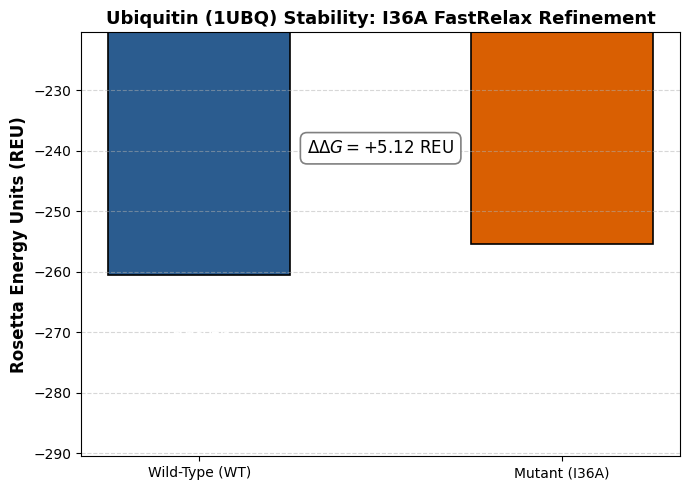

In [ ]:
import matplotlib.pyplot as plt

labels = ['Wild-Type (WT)', 'Mutant (I36A)']
scores = [wt_score, mut_score]
colors = ['#2b5c8f', '#d95f02']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, scores, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

plt.ylabel('Rosetta Energy Units (REU)', fontsize=12, fontweight='bold')
plt.title('Ubiquitin (1UBQ) Stability: I36A FastRelax Refinement', fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 12, f"{yval:.2f}",
             ha='center', va='bottom', color='white', fontweight='bold', fontsize=11)

plt.text(0.5, max(scores) + 15, rf"$\Delta\Delta G = {ddg:+.2f}\ \mathrm{{REU}}$",
         ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=1.2))

plt.ylim(min(scores) - 30, max(scores) + 35)
plt.tight_layout()
plt.savefig("ubiquitin_fastrelax_stability.png", dpi=300)
plt.show()

In [ ]:
from pyrosetta.rosetta.core.scoring import CA_rmsd, all_atom_rmsd

ca_rmsd_val = CA_rmsd(wt_pose, mutant_pose)
all_rmsd_val = all_atom_rmsd(wt_pose, mutant_pose)

print(f"Backbone C-alpha RMSD : {ca_rmsd_val:.3f} Å")
print(f"All-Atom RMSD         : {all_rmsd_val:.3f} Å")

Backbone C-alpha RMSD : 0.554 Å
All-Atom RMSD         : 0.798 Å
